In [1]:
%%writefile /tmp/study_branch.cpp
extern "C" int branchy(int n) {
    if (n % 15 == 0) return 0;
    else if (n % 3 == 0) return 1;
    else if (n % 5 == 0) return 2;
    else return 3;
}

Overwriting /tmp/study_branch.cpp


In [2]:
!g++ -std=c++23 -O3 -c /tmp/study_branch.cpp -o /tmp/study_branch.o

In [3]:
import pandas as pd

import perf

frames = []
for branch in ("predictable", "unpredictable"):
    df = perf.bench(
        exec="/tmp/study_branch.o",
        func="branchy",
        mode="latency",
        event="topdown-retiring,topdown-bad-spec,topdown-fe-bound,topdown-be-bound",
        config={"branch": branch, "samples": 80, "runs": 4, "iterations": 300},
    ).reset_index()
    df["branch"] = branch
    frames.append(df)
top = pd.concat(frames, ignore_index=True)
med = top.groupby("branch")[
    ["topdown-retiring", "topdown-bad-spec", "topdown-fe-bound", "topdown-be-bound"]
].median()
pct = med.div(med.sum(axis=1), axis=0).round(3)
print(med.round(1))
print(pct)

               topdown-retiring  topdown-bad-spec  topdown-fe-bound  \
branch                                                                
predictable                22.0              25.0               0.0   
unpredictable              22.0              41.0              24.0   

               topdown-be-bound  
branch                           
predictable                 1.0  
unpredictable              26.0  
               topdown-retiring  topdown-bad-spec  topdown-fe-bound  \
branch                                                                
predictable               0.458             0.521             0.000   
unpredictable             0.195             0.363             0.212   

               topdown-be-bound  
branch                           
predictable               0.021  
unpredictable             0.230  


In [4]:
import pandas as pd

import perf

frames = []
for branch in ("predictable", "unpredictable"):
    df = perf.bench(
        exec="/tmp/study_branch.o",
        func="branchy",
        mode="latency",
        event="branch-instructions,branch-misses",
        config={"branch": branch, "samples": 80, "runs": 4, "iterations": 300},
    ).reset_index()
    df["branch"] = branch
    frames.append(df)
cmp = pd.concat(frames, ignore_index=True)
cmp["mpki"] = cmp["branch-misses"] / cmp["branch-instructions"]
print(
    cmp.groupby("branch")[["branch-instructions", "branch-misses", "mpki"]]
    .median()
    .round(3)
)

               branch-instructions  branch-misses  mpki
branch                                                 
predictable                    4.0            0.0  0.00
unpredictable                  4.0            1.0  0.25


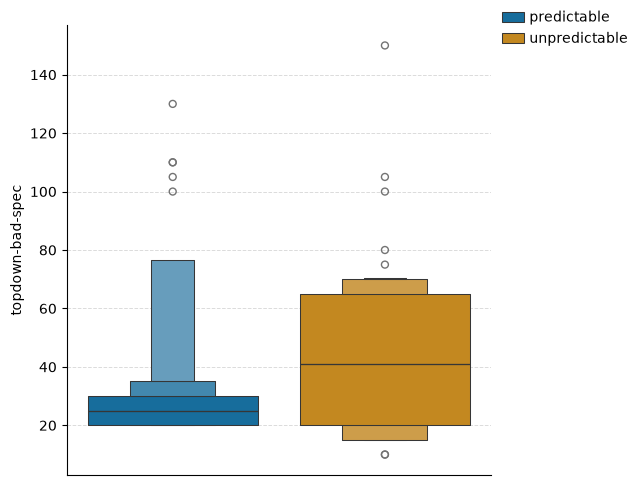

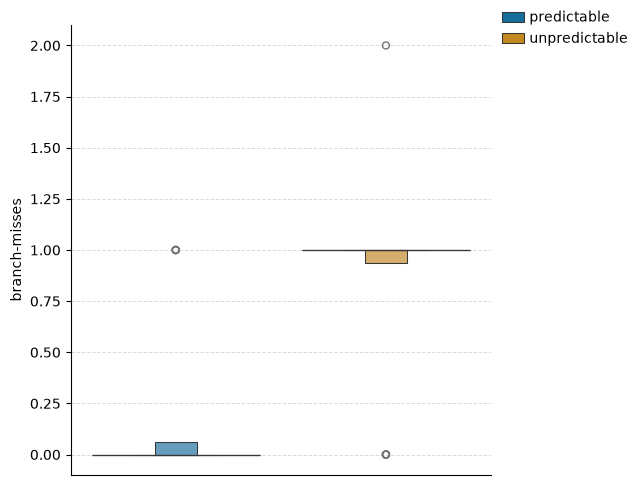

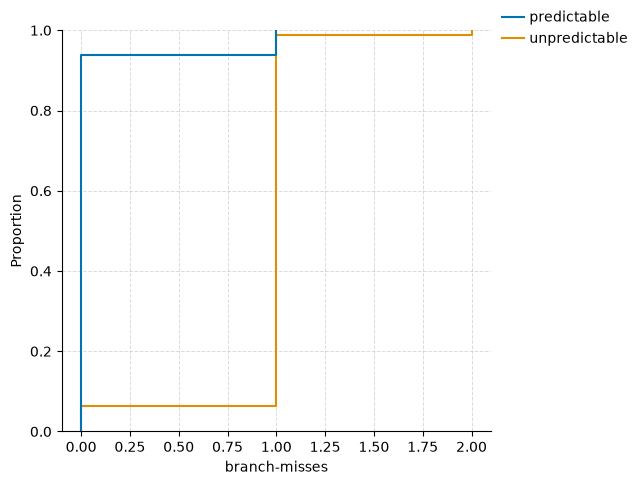

[]

In [5]:
perf.plot(top, "boxen", event="topdown-bad-spec", groupby="branch")
perf.plot(cmp, "boxen", event="branch-misses", groupby="branch")
perf.plot(cmp, "ecdf", event="branch-misses", groupby="branch")